# Mall_Customers

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Admin\hipython\data\Mall_Customers.csv')
print(df.head())
print(df.shape)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


In [4]:
# CustomerID 제거, 성별 인코딩
df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values


# StandardScaler로 x 스케일링


In [5]:
# StandardScaler로 x 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA : 2개의 주성분으로 압축

In [6]:
# PCA : 2개의 주성분으로 압축
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"누적 설명 분산: {sum(pca.explained_variance_ratio_):.4f}")

설명된 분산 비율: [0.33690046 0.26230645]
누적 설명 분산: 0.5992


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


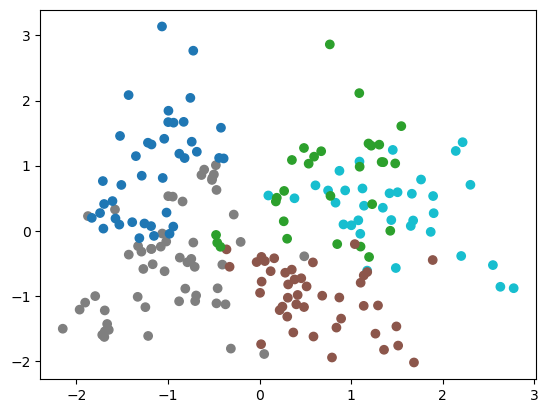

In [10]:
# 더 정확한 분석을 원한다면
# KMeans는 원본 스케일링 데이터로, PCA는 시각화용으로만 사용

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)   # ← PCA 아닌 원본으로 클러스터링

# 시각화만 PCA 2D로
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')

# KMEANS 클러스터링 


In [12]:
# KMEANS 클러스터링 수행
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

print(f"클러스터 레이블: {np.unique(labels)}")
print(f"각 클러스터 샘플 수: {np.bincount(labels)}")
print(f"이너셔(Inertia): {kmeans.inertia_:.2f}")

클러스터 레이블: [0 1 2 3 4]
각 클러스터 샘플 수: [39 29 43 54 35]
이너셔(Inertia): 331.31


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
# KMEANS 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)
print(f"클러스터 레이블: {np.unique(labels)}")
print(f"각 클러스터 샘플 수: {np.bincount(labels)}")

클러스터 레이블: [0 1 2 3]
각 클러스터 샘플 수: [34 51 54 61]


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

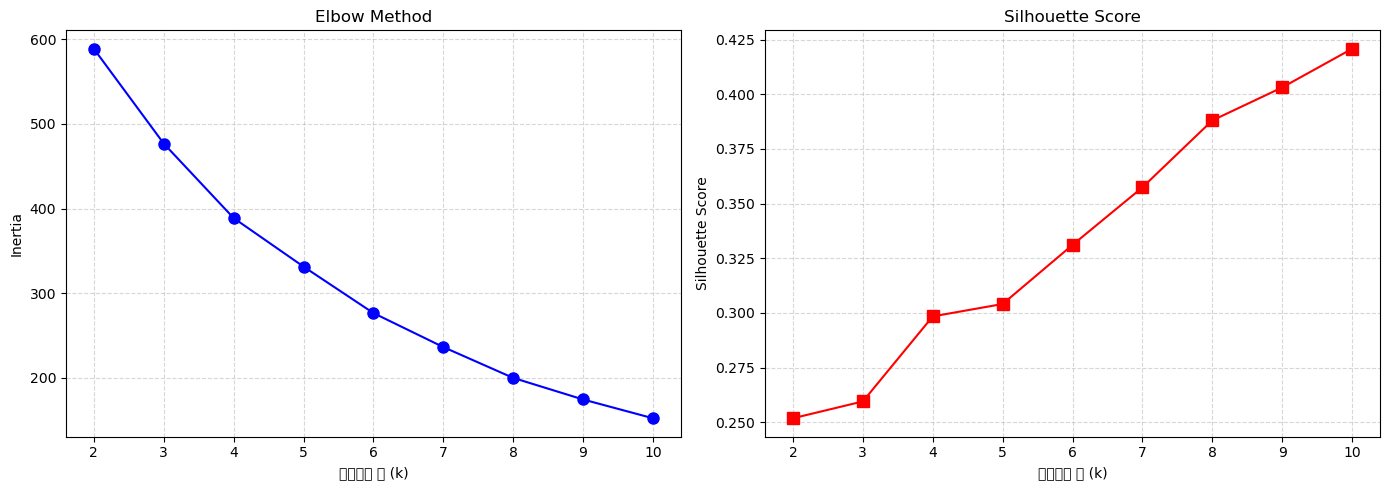

   k |    Inertia | Silhouette
------------------------------
   2 |     588.80 |     0.2518
   3 |     476.79 |     0.2595
   4 |     388.72 |     0.2984
   5 |     331.31 |     0.3041
   6 |     276.41 |     0.3311
   7 |     236.20 |     0.3574
   8 |     199.75 |     0.3880
   9 |     174.24 |     0.4031
  10 |     152.03 |     0.4208


In [13]:
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertia_list, 'bo-', markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette Score
axes[1].plot(k_range, silhouette_list, 'rs-', markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 수치 출력
print(f"{'k':>4} | {'Inertia':>10} | {'Silhouette':>10}")
print("-" * 30)
for k, inertia, sil in zip(k_range, inertia_list, silhouette_list):
    print(f"{k:>4} | {inertia:>10.2f} | {sil:>10.4f}")

# KMeans 클러스터링 결과 시각화

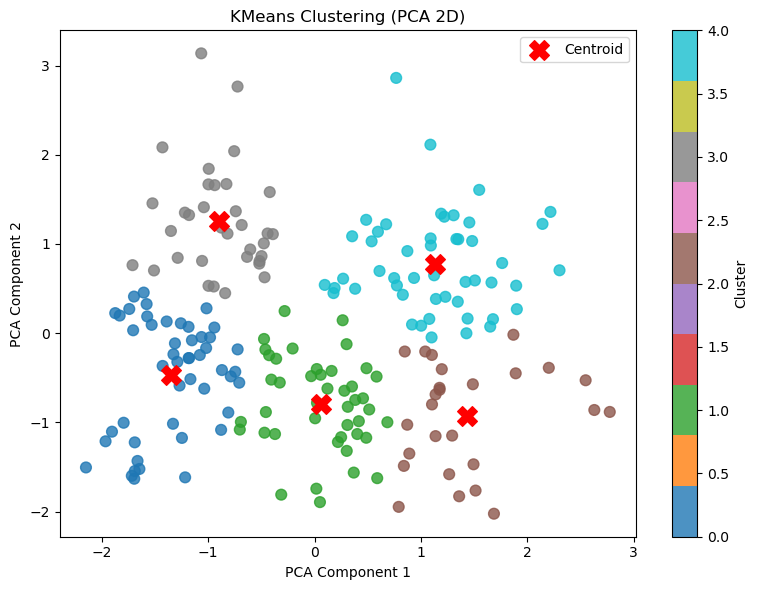

In [8]:
# KMeans 클러스터링 결과 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=60, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.title('KMeans Clustering (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


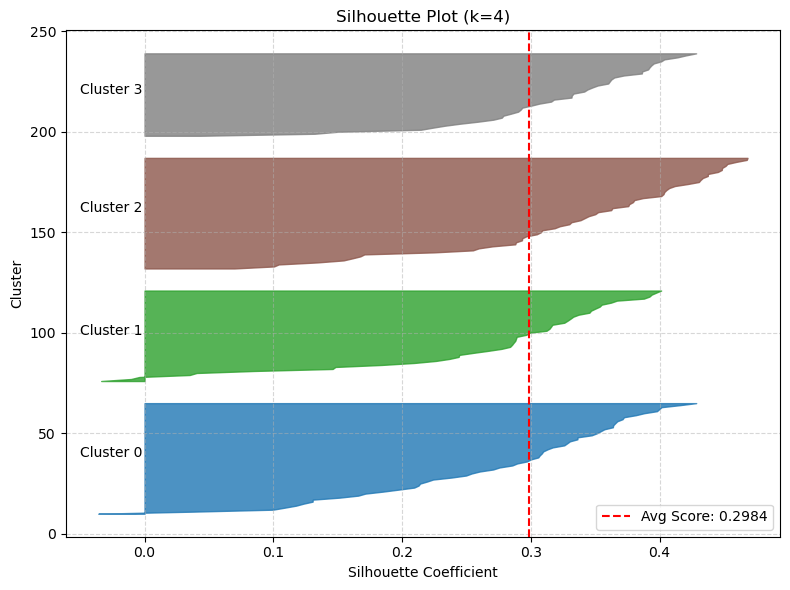

k=4 평균 Silhouette Score: 0.2984


In [19]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

silhouette_vals = silhouette_samples(X_scaled, labels)
avg_score = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(k):
    cluster_vals = np.sort(silhouette_vals[labels == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size

    color = cm.tab10(i / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg Score: {avg_score:.4f}')
ax.set_title(f'Silhouette Plot (k={k})')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"k={k} 평균 Silhouette Score: {avg_score:.4f}")

In [24]:
# 클러스터 컬럼 추가 (만약 없으면)
#cust_df['cluster_4'] = clusters

# 주요 피처 선택
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# 그룹별 요약
cluster_summary = cust_df.groupby('cluster_4')[features].mean().round(2)
cluster_counts = cust_df['cluster_4'].value_counts().sort_index()

# 클러스터별 샘플 수도 함께 표시
cluster_summary['Count'] = cluster_counts

print(cluster_summary)

NameError: name 'cust_df' is not defined

In [17]:
X_pca


array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

In [ ]:
# 1. ID 제거

In [ ]:
cust_df = cust_df.drop('CustomerID', axis=1)

In [ ]:
# 2. Gender 인코딩

In [ ]:
cust_df['Gender'] = cust_df['Gender'].map({'Male':0, 'Female':1})

In [ ]:
# 3. 피처 분리

In [ ]:
X = cust_df[['Gender', 'Age',
             'Annual Income (k$)',
             'Spending Score(1-100)']]

In [ ]:
# 4. 스케일링

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)